# Customer Segmentation

### Key objective: Help the organization increase revenue and customer loyalty by identifying meaningful customer segments based on purchasing behavior and customer characteristics. Which customer segments are most valuable, and how should they be targeted?

#### Steps: 
1. Data exploration and cleaning
2. Customer segmentation using hierarchical clustering
3. Cluster profiling, recommendations and validation

## 1. Data exploration and cleaning

In [38]:
# Load dataset
#!pip install pandas
import pandas as pd
df =  pd.read_csv("marketing_campaign.csv", sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [41]:
# How many customers are in the dataset? Each row represents a customer
print("Dataset contains of:", len(df), "rows/unique customers")

Dataset contains of: 2240 rows/unique customers


In [50]:
# Create a variable for total amount spent in the last two years
df["Total_spending"]=(
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

# Create a variable for age 
df["Age"] = 2014 - df["Year_Birth"]

In [44]:
# Missing values in each column 
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Total_spending          0
Age                     0
dtype: int64

Only 24 missing values in Income column. Easiest is to remove those, however lets do simple inputation strategy to retain as many customers as possible for the segmentation analysis. 

In [46]:
# Imputation strategy for column Income. The median is used for this column 
df["Income"] = df["Income"].fillna(df["Income"].median())

In [61]:
# Check the numeric variables 

# Expand display to show all columns
pd.set_option('display.max_columns', None)

df.describe()

,ID,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Total_spending,Age
count,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000
mean,5590.726419,52227.407689,0.444345,0.506482,49.104604,303.995530,26.270451,166.916853,37.523022,27.068842,43.968708,2.326777,4.087170,2.662494,5.794367,5.319177,0.072865,0.074654,0.072418,0.064372,0.013411,0.008941,0.149307,605.743406,45.098346
std,3245.118591,25043.266830,0.538467,0.544593,28.956073,336.574382,39.715972,225.661158,54.639909,41.293949,52.054318,1.932923,2.779461,2.923456,3.250940,2.426386,0.259974,0.262890,0.259237,0.245469,0.115052,0.094152,0.356471,601.840466,11.701917
min,0.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,18.000000
25%,2829.000000,35523.000000,0.000000,0.000000,24.000000,24.000000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.000000,37.000000
50%,5455.000000,51381.500000,0.000000,0.000000,49.000000,174.000000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,396.000000,44.000000
75%,8427.000000,68281.000000,1.000000,1.000000,74.000000,504.000000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1045.000000,55.000000
max,11191.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2525.000000,74.000000


Most customers have relatively few children, with 75% of customers have at most one child and at most one teenager living at home. In addition, 75% of customers have an income of 68.291 euro or less, while spending 1045 euro or less. 

In [59]:
# Remove customers older than 100 years (Outliers)
df = df[df["Age"] <= 100]

# Lets remove two columns with no variance (Z_CostContact = Cost of contracting a customer and Z_Revenue = REvenue generated from a succesful campaign)
df.drop(columns=['Z_CostContact', 'Z_Revenue', 'Year_Birth'], inplace=True)

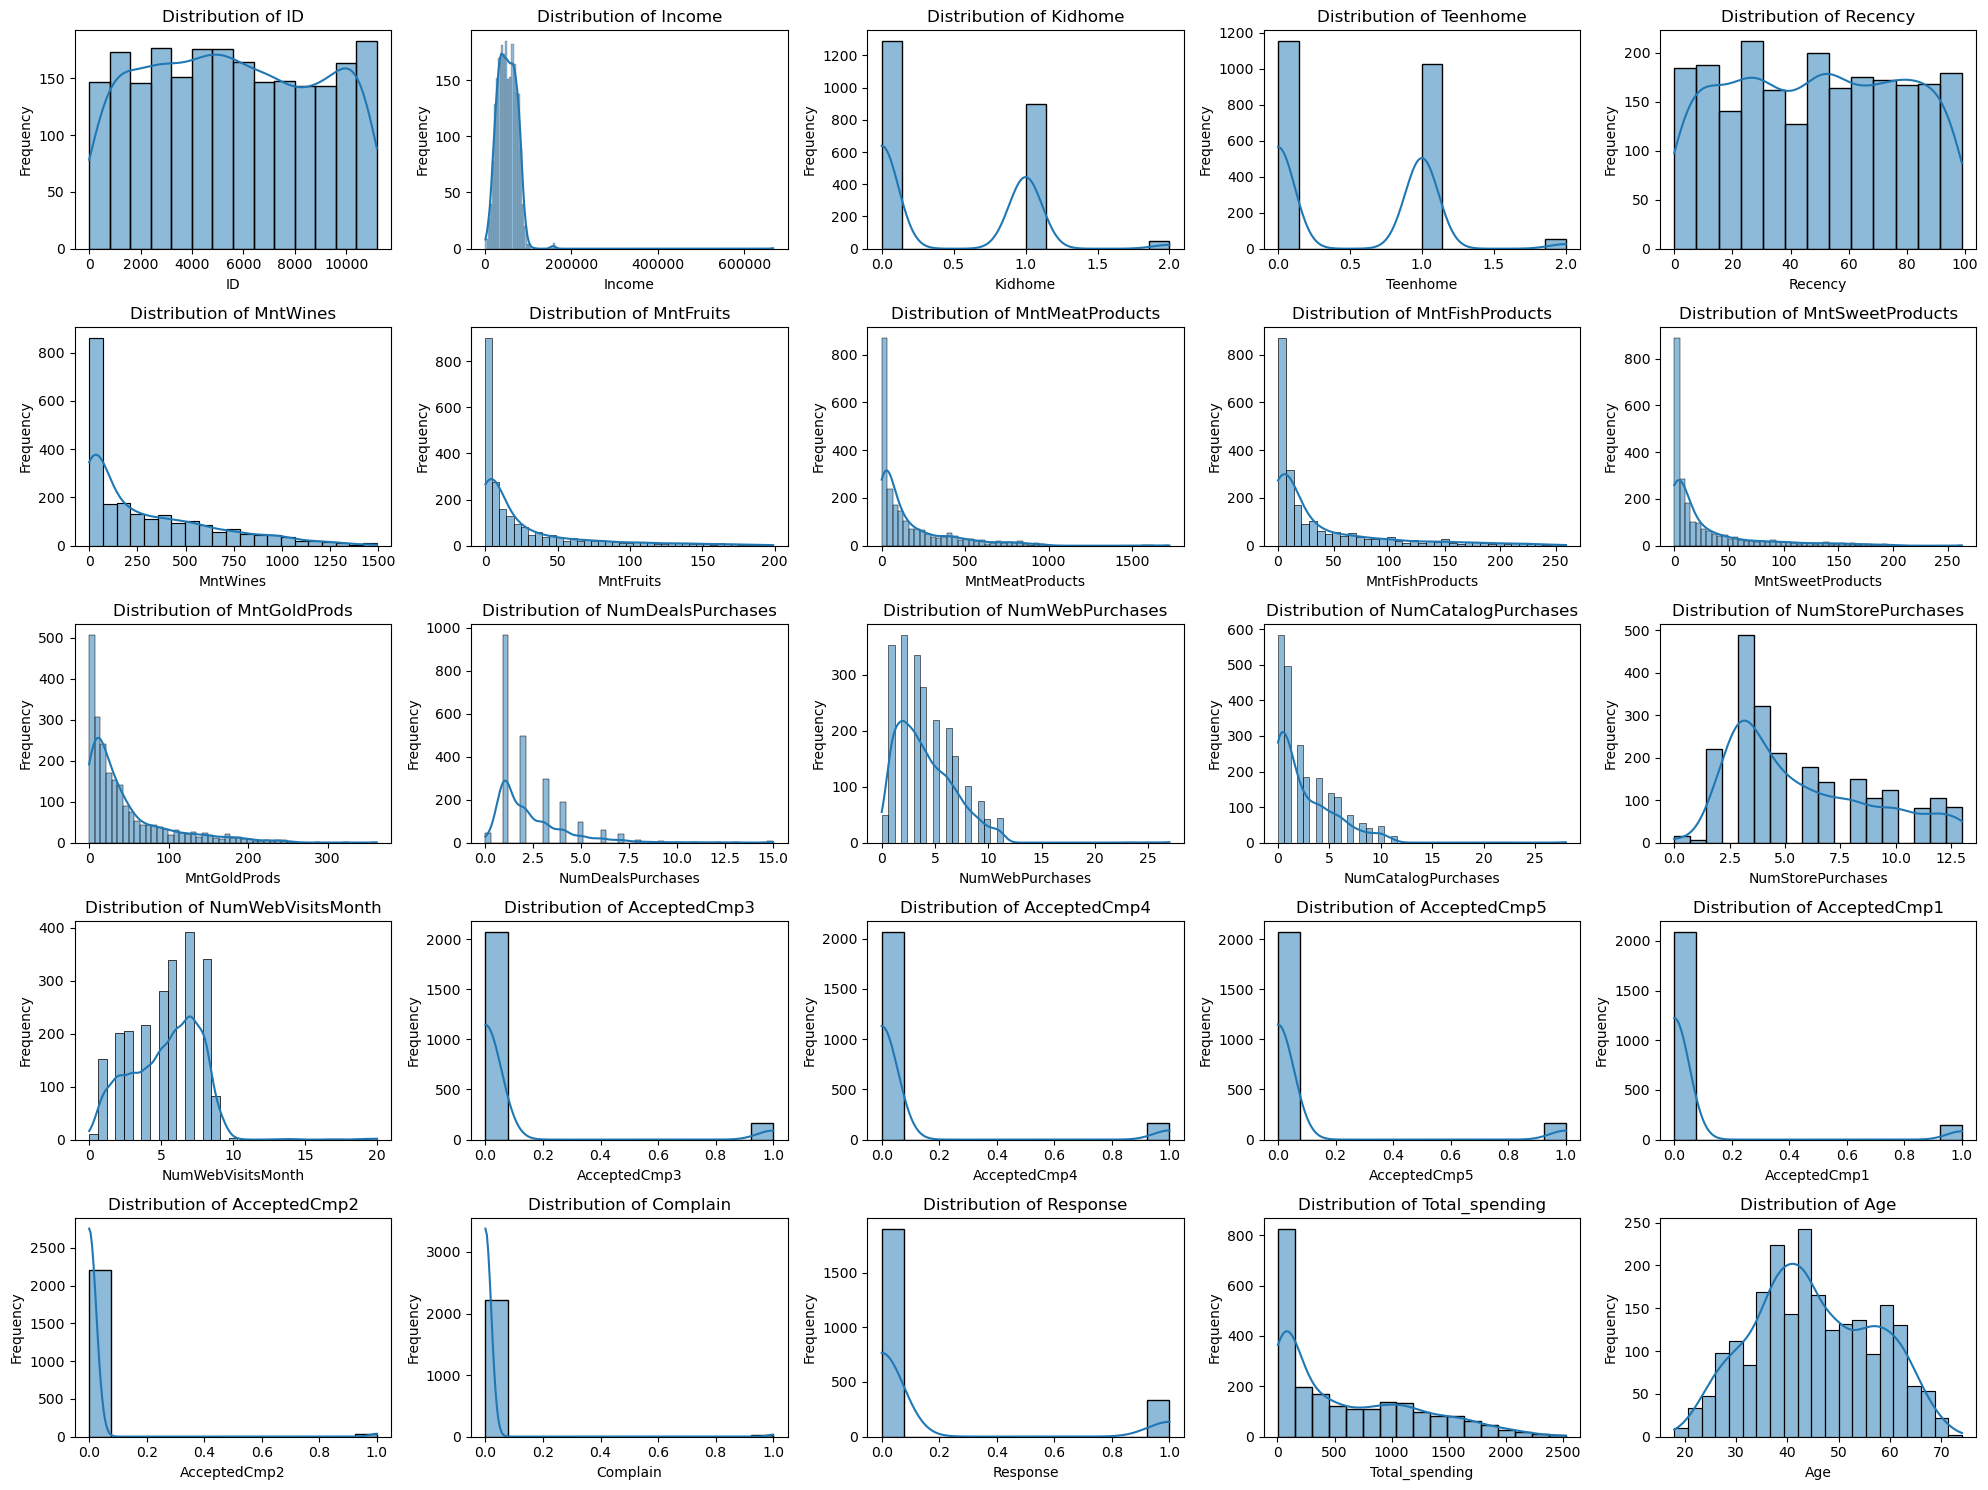

In [60]:
# Plot distribution of each column 
#!pip install matplotlib
#!pip install seaborn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns 
numeric_cols = df.select_dtypes(include='number').columns

# Grid layout 
n_cols = 5
n_rows = 5

# Adjust size of images in plot if needed
plt.figure(figsize=(n_cols * 4, n_rows * 3))

# Loop with index and column name 
for idx, col in enumerate(numeric_cols, 1): # Start at 1
    plt.subplot(n_rows, n_cols, idx)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
plt.tight_layout()
plt.show()

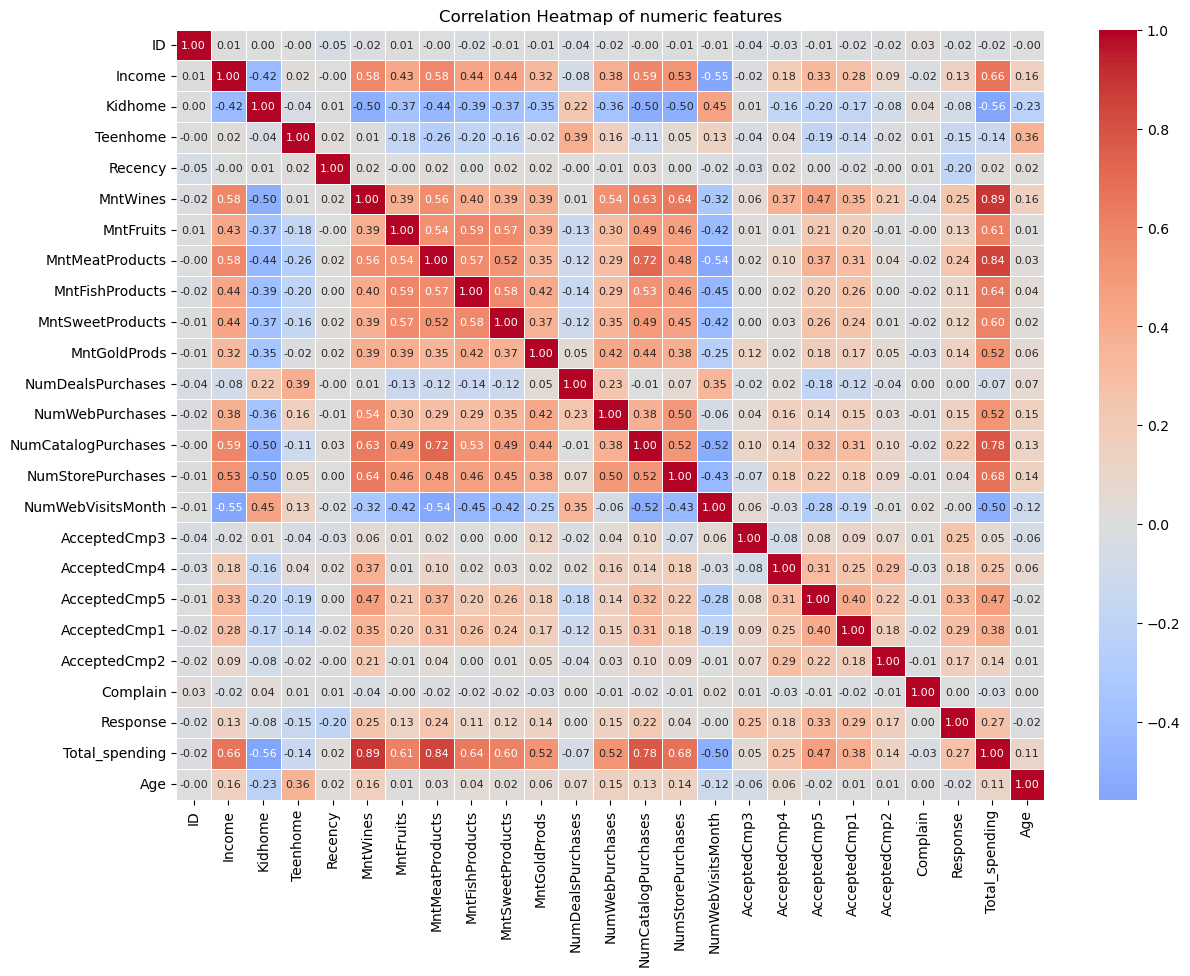

In [62]:
# Correlation between numeric variables 

# Calculate correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(14, 10))

# Create heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"size": 8})

# Add title and layout
plt.title("Correlation Heatmap of numeric features")
plt.show()

The strongest correlations with total spending are found for wine spending (0.89) and meat spending (0.84), indicating that these product categories account for a substantial part of overall customer spending. We also see that income are correlated highly (0.66) with total spending, which suggets that customers with higher income tend to spend more at the company, which may indicate that these customers should be targeted with future campaigns. There is a correlation of 0.59 between income and number of catalog purchases, which suggets that the higher income customers have, the more likely they are to buy from catalogs, which suggets targeting these groups with catelog branding. 

## 2. Customer segmentation using hierarchical clustering

#### Classical hierarchical cluster analysis using wards method (often the preferred method for stable, well defined customer segments)
The Complete Linkage method and the Wards method are the most common methods for hierarchical cluster analysis, because clusters often are meaningful, stable and same sized. Here I choose Wards method.  
We begin with standardization, because when we use distance matrix, variables with large variation can quickly dominate the analysis and we want to avoid that. 

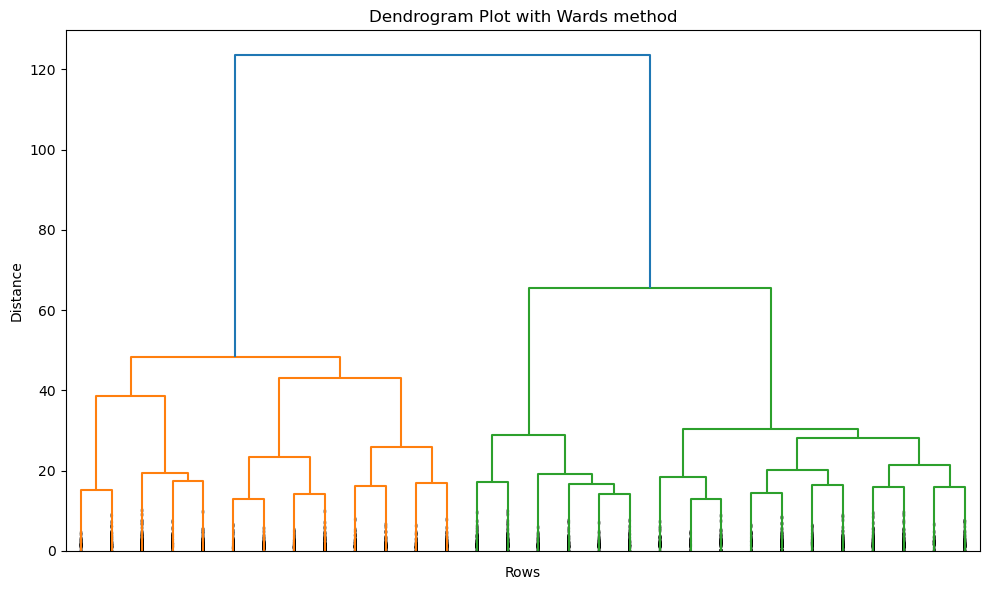

Rows before removing outliers: 2237
Rows after removing outliers: 2184
Rows removed: 53


In [96]:
#!pip install scikit-learn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram

# Create a copy of the dataset
cluster_df = df.copy()

# Variables used for clustering. We are using business relevant variables meaning variables that affect spending. Education and marital status does not effect that much for example
cluster_features = [
    "Income",
    "Age",
    "Kidhome",
    "Teenhome",
    "Recency",
    "Total_spending",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth"
]

# Calculate z-scores
z_scores = np.abs(zscore(cluster_df[cluster_features]))

# Remove observations with at least one z-score >= 3
cluster_df_cleaned = cluster_df[(z_scores < 3).all(axis=1)].copy()

# Feature matrix used for clustering
features_cleaned = cluster_df_cleaned[cluster_features]

# Standardize
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_cleaned)

# Ward's method
input_matrix = linkage(features_scaled, method="ward")

# Plot dendrogram
plt.figure(figsize=(10, 6))
plt.title('Dendrogram Plot with Wards method')
plt.xlabel('Rows')
plt.ylabel('Distance')

dendrogram(input_matrix, truncate_mode = 'lastp', show_leaf_counts = False, leaf_rotation = 90., leaf_font_size=12., show_contracted=True,)
plt.tight_layout()
plt.show()

# How many rows are removed with zscores
print("Rows before removing outliers:", len(cluster_df))
print("Rows after removing outliers:", len(cluster_df_cleaned))
print("Rows removed:", len(cluster_df) - len(cluster_df_cleaned))

First of all, we have removed 53 outliers detected with zscores. These customers were too extreme. The dendrogram shows how the clusters are gradially put together. We start with many small clusters at the bottom. The last merges are at the top. The last two clusters merge at a distance of 120 (we go from 2 to 1 cluster), while at around a distance of 70 we go from 3 clusters to 2 clusters. At a distance of 50 we go from 4 clusters to 3 clusters. We are looking for the place, where the distance increases dramatically, which is where two clusters are merged but very different. Ideally we stop right before this big increase in distance.  

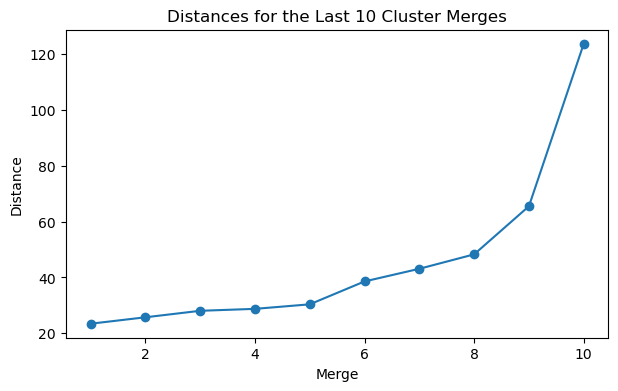

In [97]:
# Assess % increase in distance to decide on how many clusters
from scipy.cluster.hierarchy import linkage, fcluster
import numpy as np

last = input_matrix[-10:, 2]

plt.figure(figsize=(7,4))
plt.plot(range(1,11), last, marker="o")

plt.xlabel("Merge")
plt.ylabel("Distance")
plt.title("Distances for the Last 10 Cluster Merges")

plt.show()

Here we see the last 10 merges. We are looking for places where there is a large increase in distance, which happens at distance 50 to 65 and also at 65 to 120. So there is two places, where the algorithm starts to merge very different groups together. The last merge is when we go from 2 clusters to 1 cluster. A size of this increase it telling that the two groups differ a lot. Lets look at the other large jump in distance. Remember we are only looking at the last 10 merges. In total we had 2184 customers, which mean we have 2183 merges in total. Since we are looking at the last 10 merges we know that the last merge has to be 2 clusters to 1 cluster. Therefore merge number 9 has to be where we go from 3 clusters to 2 clusters, while merge number 8 has to be where we go from 4 clusters to 3 clusters and so forward. The second large increase in distance happens at merge 9, where we go from 3 clusters to 2 clusters. This suggest that we should probably end the analysis with 3 clusters rather than 2 clusters. Accordingly, 3 clusters seems like the optimal number. However lets now assess the silhouette scores for cluster 2-5 to see if they agree.   

In [99]:
# Assess the Silhouette scores for the clusters between 2 and 5 clusters
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 6):
    labels = fcluster(input_matrix, k, criterion="maxclust")
    score = silhouette_score(features_scaled, labels)
    scores.append(score)
    print(f"{k} clusters: {score:.3f}")

2 clusters: 0.286
3 clusters: 0.246
4 clusters: 0.175
5 clusters: 0.182


The Silhuette score measures how well an observation (a customer) fits with its own cluster compared to other clusters. The scores go from -1 to 1. The larger score, the better segmentation. We see that 2 clusters give the best segmentation. When we have 3 clusters, the quality of the segmentation goes down a bit. Deviding the customers into 4 or 5 clusters provides weak seperations of the customers. Overall, the silhuette analysis suggest that a 2 cluster solution provides the strongest seperation between customers (silhuette = 0.286). However, while the clustering quality decreases as the number of clusters increases, solutions with 4 or 5 clusters provide substantially more detailed customer segments, for example such as high risk of churn customers, low activity customers, loyals, new ones etc. These would probably be more useful from a managerial perspective. Both the Silhouette score and increase in distance plot suggest that a small number of clusters provides the strongest statistical separation. However, solutions with only two or three clusters provide limited managerial insights. Therefore, a 5-cluster solution is selected as a compromise between statistical quality and business usefulness.

In [ ]:
## 3. Cluster profiling, recommendations and validation

In [102]:
# 5-cluster solution
from scipy.cluster.hierarchy import fcluster

cluster_df_cleaned["Cluster5"] = fcluster(
    input_matrix,
    5,
    criterion="maxclust"
)

# How many customers are in each cluster?
display(cluster_df_cleaned["Cluster5"].value_counts().sort_index())

# Define numerical profiling variables
profile_vars = [
    "Income",
    "Age",
    "Total_spending",
    "Recency",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "Kidhome",
    "Teenhome"
]

display(
    cluster_df_cleaned
    .groupby("Cluster5")[profile_vars]
    .mean()
    .round(1)
)

# Lets see how the clusters differ on education, marital status and responsives towards marketing campaigns as well: 
# Education distribution within each cluster (%)
display(
    pd.crosstab(
        cluster_df_cleaned["Education"],
        cluster_df_cleaned["Cluster5"],
        normalize="columns"
    ).mul(100).round(1)
)

# Marital status distribution within each cluster (%)
display(
    pd.crosstab(
        cluster_df_cleaned["Marital_Status"],
        cluster_df_cleaned["Cluster5"],
        normalize="columns"
    ).mul(100).round(1)
)

# Response distribution within each cluster (%)
display(
    pd.crosstab(
        cluster_df_cleaned["Response"],
        cluster_df_cleaned["Cluster5"],
        normalize="columns"
    ).mul(100).round(1)
)

Cluster5
1    424
2    432
3    255
4    436
5    637
Name: count, dtype: int64

,Income,Age,Total_spending,Recency,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,Kidhome,Teenhome
Cluster5,,,,,,,,,,,
1,41951.6,47.5,169.9,50.1,2.9,0.8,3.7,3.3,6.4,1.1,0.9
2,30156.6,35.4,87.6,49.5,2.2,0.4,3.1,1.9,6.9,1.0,0.0
3,37105.3,45.5,143.6,49.3,2.4,0.8,3.7,1.4,5.7,0.0,0.6
4,76303.0,46.0,1371.5,51.8,4.4,5.9,8.3,1.0,2.2,0.0,0.0
5,61860.7,49.2,890.4,47.0,6.5,3.8,8.2,2.8,5.3,0.1,0.9


Cluster5,1,2,3,4,5
Education,,,,,
2n Cycle,9.4,11.3,11.4,8.0,7.2
Basic,0.5,7.4,7.5,0.0,0.2
Graduation,49.1,51.2,45.5,52.1,52.3
Master,17.9,14.6,18.0,18.1,14.9
PhD,23.1,15.5,17.6,21.8,25.4


Cluster5,1,2,3,4,5
Marital_Status,,,,,
Absurd,0.0,0.0,0.0,0.5,0.0
Alone,0.5,0.2,0.0,0.0,0.0
Divorced,11.3,8.3,9.0,8.3,13.2
Married,38.7,39.4,41.2,36.0,38.8
Single,18.6,25.9,21.2,25.2,17.3
Together,27.4,25.7,24.3,25.5,26.1
Widow,3.5,0.5,4.3,4.6,4.4
YOLO,0.0,0.0,0.0,0.0,0.3


Cluster5,1,2,3,4,5
Response,,,,,
0,89.9,87.3,95.3,71.6,86.2
1,10.1,12.7,4.7,28.4,13.8


Bases on above, we can now start profile each segment based on customer behavior and give each of them an appropriate name that describes them. 

Cluster 1 - Discount shoppers
- 424 customers
- Highest number of discount purchases
- Many children living at home
This segment appears highly price-sensitive and respons well to discounts. Future campaigns should focus on promotions, coupons and bundle offers to encourage repeat purchases while avoiding unneccessary discounts on premium products. 


Cluster 2 - Price sensitive browsers
- 432 customers
- Lowest income
- Lowest spending
- The youngest
- Highest number of monthly web vists
- Many has kids but no teenagers
This segment shows high online engagement but low purchasing activity. They therefore appear interested in the company's products, but they rarely convert into purchases. The company should focus on converting these visitors into customers through personalized offers, entry-level products and targeted promotions.

Cluster 3 - Marketing-Resistant customers
- 255 customers
- Many has teenagers but no kids
- Lowest response rate
This segment is the least responsive to marketing campaigns and the smallest segment. Rather than increasing campaigns frequency, the company should test alternative messages, channels or offers to better understand what motivates these customers. 

Cluster 4 - High value customers
- 436 customers
- Highest income
- Highest spending
- Highest number of catalog and store purchases
- No children living home
- Least frequently buyers
- Highest response rate
This segment appear to be the top spending segment and are the one that responds the most positive in regard to marketing campaigns. They make fewer but larger purchases. They represent the company's most valuable customers. Marketing efforts should focus on retaining these customers through exclusive offers, premium products and loyality programs rather than frequent discount campaigns. 

Cluster 5 - Responsive online customers 
- 637 customers
- Highest number of website purchases
- Mostly teenagers at home, a few has younger siblings
- Most frequently buyers 
- Second highest response rate
These customers appear highly engaged with the company's online channels and they respond well to marketing campaigns. Future digitally marketing campaigns and perhaps loyality iniatitives should therefore prioritize this segment, which is the largest segment out of the five.   

In [ ]:
#### 2.3 Criterion validation - Does the segments also differ on other variables?

Criterion validation examines whether the identified clusters also differ on relevant variables that were not used to create the clusters. Meaningful differences would provide additional support for the usefulness of the segmentation.

In [103]:
# Create profiling dataset
df_profile = df.loc[cluster_df_cleaned.index].copy()
df_profile["Cluster5"] = cluster_df_cleaned["Cluster5"].values

# Variables not used for clustering
validation_vars = [
    "Response",
    "Complain",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]

# Average values for each cluster
display(
    df_profile.groupby("Cluster5")[validation_vars].mean().round(3)
)

,Response,Complain,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
Cluster5,,,,,,,
1,0.101,0.012,0.009,0.005,0.068,0.021,0.000
2,0.127,0.014,0.000,0.000,0.100,0.000,0.000
3,0.047,0.004,0.004,0.000,0.035,0.027,0.000
4,0.284,0.007,0.232,0.032,0.069,0.133,0.284
5,0.138,0.008,0.057,0.022,0.077,0.140,0.053


Here we see how the segments differ across variables not included in the cluster analysis. The average values indicate that the identified customer segments differ in their responsiveness to marketing campaigns. In particular cluster 4 has the highest acceptance rates for campaigns 1, 4 and 5. In contrast, cluster 3 has the lowest response rate and generally the lowest campaign acceptance rates together with cluster 2. The remaining clusters show intermediate levels of responsiveness, suggesting meaningful behavioural differences between the customer segments. 

In [105]:
# ANOVA tests - Is the above differences statistical significant or not?

# ANOVA test on Response and Complain 
from scipy.stats import f_oneway

print("ANOVA results:")

for var in validation_vars:

    groups = [
        df_profile.loc[df_profile["Cluster5"] == c, var]
        for c in sorted(df_profile["Cluster5"].unique())
    ]

    f_stat, p_value = f_oneway(*groups)

    print(f"{var:<15} F = {f_stat:6.2f}   p = {p_value:.4f}")

ANOVA results:
Response        F =  24.63   p = 0.0000
Complain        F =   0.63   p = 0.6399
AcceptedCmp1    F =  75.92   p = 0.0000
AcceptedCmp2    F =   6.61   p = 0.0000
AcceptedCmp3    F =   2.56   p = 0.0370
AcceptedCmp4    F =  32.00   p = 0.0000
AcceptedCmp5    F = 115.56   p = 0.0000


The ANOVA tests answers whether all clusters has the same average on a variable (H0) or at least one cluster differs from the others (H1).
Significant differences were found for Response and all five AcceptedCmp variables (p < 0.05), while no significant difference was found for Complain (P=0.640). Overall, the results support and satisfy the criterion validity of the segmentation, as the clusters show meaningful differences on marketing variables that were not used to create the clusters. This provides support that the segments represent real and relevant differences. 

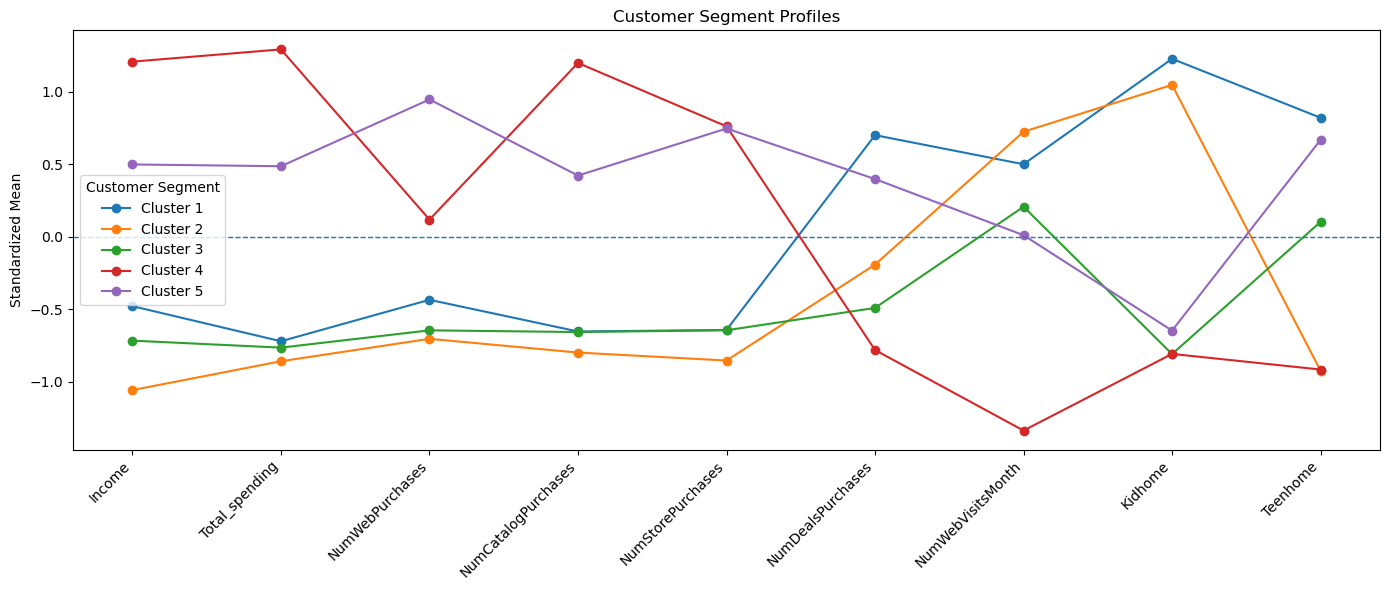

In [109]:
# Snake plot for ReadME file 

# Variables for the cluster profile plot
profile_vars = [
    "Income",
    "Total_spending",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "Kidhome",
    "Teenhome"
]

# Standardize variables
profile_scaled = StandardScaler().fit_transform(
    cluster_df_cleaned[profile_vars]
)

# Convert to DataFrame
profile_scaled = pd.DataFrame(
    profile_scaled,
    columns=profile_vars,
    index=cluster_df_cleaned.index
)

# Add cluster labels
profile_scaled["Cluster"] = cluster_df_cleaned["Cluster5"]

# Calculate average standardized value for each cluster
cluster_profiles = profile_scaled.groupby("Cluster").mean()

# Plot
plt.figure(figsize=(14, 6))

for cluster in cluster_profiles.index:
    plt.plot(
        profile_vars,
        cluster_profiles.loc[cluster],
        marker="o",
        label=f"Cluster {cluster}"
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Customer Segment Profiles")
plt.xlabel("")
plt.ylabel("Standardized Mean")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Customer Segment")
plt.tight_layout()
plt.savefig("customer_segment_profiles.png", dpi=300, bbox_inches="tight")

plt.show()